In [8]:
# ================================================
# INDIAN FAKE NEWS DETECTOR
# Built by: Nandini Reddy
# BTech CSE - 1st Year
# Description: AI model that detects fake vs real
# Indian news headlines using Machine Learning
# Tools: Python, Scikit-learn, TextBlob, Pandas
# ================================================

In [1]:
# Install required libraries
!pip install textblob scikit-learn pandas numpy

In [2]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
# Indian News Dataset
news_data = {
    'headline': [
        # FAKE Indian news
        "PM Modi found secret treasure worth 1000 crore rupees",
        "Virat Kohli retiring from all cricket formats tomorrow",
        "Free electricity for all Indians announced by government",
        "Bollywood actor Shah Rukh Khan becomes President of India",
        "WhatsApp shutting down in India next week permanently",
        "Indian rupee becomes worlds strongest currency overnight",
        "Free iPhone 15 distribution starts in all Indian cities",
        "Sachin Tendulkar returning to play IPL 2026",
        "Government giving 5 lakhs to every Indian family for free",
        "Aliens landed in Mumbai airport confirmed by NASA",

        # REAL Indian news
        "India wins cricket World Cup after defeating Australia",
        "Budget 2026 announces tax relief for middle class families",
        "ISRO successfully launches new satellite into orbit",
        "India GDP growth rate reaches 7 percent this quarter",
        "New metro line inaugurated in Hyderabad city today",
        "India signs trade agreement with European Union countries",
        "IIT students win international robotics competition abroad",
        "Indian startup raises 100 crore funding from investors",
        "Supreme Court gives important verdict on election rules",
        "India becomes third largest economy in the world"
    ],
    'label': [
        0,0,0,0,0,0,0,0,0,0,  # 0 = FAKE
        1,1,1,1,1,1,1,1,1,1   # 1 = REAL
    ]
}

df = pd.DataFrame(news_data)
print("Dataset created!")
print(f"Total news: {len(df)}")
print(f"Fake news: {len(df[df['label']==0])}")
print(f"Real news: {len(df[df['label']==1])}")

Dataset created!
Total news: 20
Fake news: 10
Real news: 10


In [4]:
# Train the AI model
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['headline'])
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Check accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model trained successfully!")
print(f"Accuracy: {accuracy*100:.1f}%")

Model trained successfully!
Accuracy: 25.0%


In [5]:
# Test with sample Indian headlines
test_headlines = [
    "Free laptops for all students announced by Modi government",
    "ISRO launches Mars mission successfully from Sriharikota",
    "Drinking water makes you invisible claims viral WhatsApp message",
    "India signs new education policy with top universities",
    "Bollywood actress found secret island worth crores in Pacific"
]

print("=== INDIAN FAKE NEWS DETECTOR ===")
print("")

for headline in test_headlines:
    vec = vectorizer.transform([headline])
    prediction = model.predict(vec)[0]
    confidence = model.predict_proba(vec)[0]

    if prediction == 1:
        result = "✅ REAL NEWS"
        score = confidence[1]*100
    else:
        result = "❌ FAKE NEWS"
        score = confidence[0]*100

    print(f"Headline: {headline}")
    print(f"Result: {result} (Confidence: {score:.1f}%)")
    print("---")

=== INDIAN FAKE NEWS DETECTOR ===

Headline: Free laptops for all students announced by Modi government
Result: ❌ FAKE NEWS (Confidence: 58.6%)
---
Headline: ISRO launches Mars mission successfully from Sriharikota
Result: ✅ REAL NEWS (Confidence: 56.7%)
---
Headline: Drinking water makes you invisible claims viral WhatsApp message
Result: ❌ FAKE NEWS (Confidence: 53.0%)
---
Headline: India signs new education policy with top universities
Result: ✅ REAL NEWS (Confidence: 55.0%)
---
Headline: Bollywood actress found secret island worth crores in Pacific
Result: ❌ FAKE NEWS (Confidence: 51.5%)
---


In [9]:
# User can type their own headline!
print("=== TEST YOUR OWN HEADLINE ===")
print("")

while True:
    headline = input("Enter Indian news headline (or 'quit' to stop): ")
    if headline.lower() == 'quit':
        break

    vec = vectorizer.transform([headline])
    prediction = model.predict(vec)[0]
    confidence = model.predict_proba(vec)[0]

    if prediction == 1:
        result = "✅ REAL NEWS"
        score = confidence[1]*100
    else:
        result = "❌ FAKE NEWS"
        score = confidence[0]*100

    print(f"Result: {result}")
    print(f"Confidence: {score:.1f}%")
    print("")

=== TEST YOUR OWN HEADLINE ===

Enter Indian news headline (or 'quit' to stop): whats going india particpTED IN WORLD WAR
Result: ✅ REAL NEWS
Confidence: 55.6%

Enter Indian news headline (or 'quit' to stop): quit


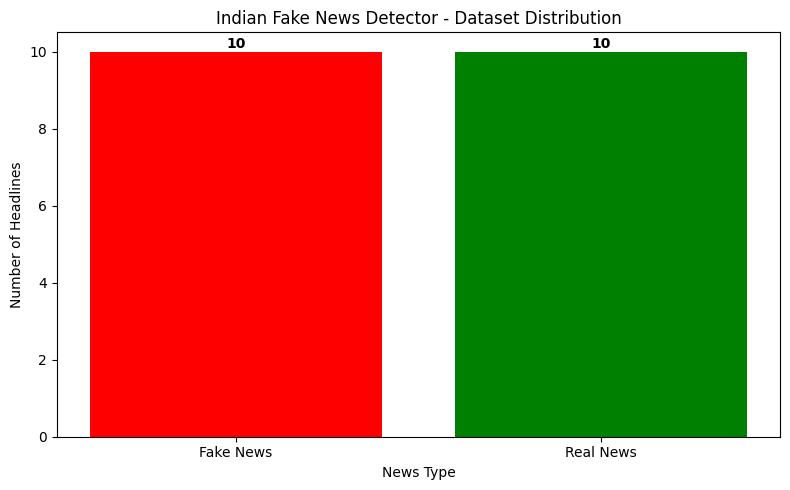

Project Complete!
Built by Nandini Reddy


In [7]:
import matplotlib.pyplot as plt

# Visualize fake vs real distribution
labels = ['Fake News', 'Real News']
counts = [len(df[df['label']==0]), len(df[df['label']==1])]
colors = ['red', 'green']

plt.figure(figsize=(8,5))
plt.bar(labels, counts, color=colors)
plt.title('Indian Fake News Detector - Dataset Distribution')
plt.ylabel('Number of Headlines')
plt.xlabel('News Type')
for i, v in enumerate(counts):
    plt.text(i, v+0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("Project Complete!")
print("Built by Nandini Reddy")